In [1]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
pd.set_option("display.max_colwidth", None)

In [3]:
df = Path("/home/User25/avito_airi_3_case/data")

In [4]:
needs = pd.read_json(
    df / "needs.train.jsonl",
    lines=True
)

needs.head()

,need_id,need_text
0,N_ebc9559a424de306b0dc1b4a,Некоммерческой организации требуется специалист в области дизайна. Задача — Создание 3D-модели животных для печати на 3D-принтере и анимированной заставки под новый логотип проекта. Модель необходима для брендированной продукции и заставка — для идентификации проекта. Требуется техническое задание и примеры для ориентира. Ожидаемый результат — комплект элементов фирменного стиля. Формат работы: дистанционно.
1,N_f2365df8c9e0e164bcfe642f,"Некоммерческой организации требуется специалист по фото, видео или анимации. Задача — создать анимационный ролик в игровом стиле, объясняющий медицинский процесс. Необходимы иллюстрации персонажей и плавная анимация. Длительность 3-4 минуты. Ролик должен быть в формате MP4, оптимизирован для соцсетей. Важно, чтобы анимация была понятной и эмоционально нейтральной, чтобы снизить стресс у аудитории. Ожидаемый результат — готовый анимационный ролик. Формат работы: дистанционно."
2,N_f736b2786a4ba70e69b82c54,"Некоммерческой организации требуется специалист по фото, видео или анимации. Задача — создать серию 3D-анимаций сердца с эффектом кинцуги, а также анимационные обложки для подкаста. Сердце должно быть условным, с трещинами, заполняемыми золотыми швами. Также требуется 24 анимационных обложки в заданных цветовых решениях. Видео должны быть оптимизированы для веба, в формате WebM/MP4/GIF, размер 1080х1080 px. Ожидаемый результат — готовый анимационный ролик. Формат работы: дистанционно."
3,N_d7b293dde3307f437cd86295,"Некоммерческой организации требуется специалист по фото, видео или анимации. Задача — Создать 2D-анимацию из нескольких кадров, включая элементы, которые помогут привлечь внимание к благотворительной акции. Анимация должна быть в формате видео, вертикальной ориентации, длительностью до 1 минуты. Важно использовать HD-качество. Результат будет использоваться в социальных сетях и на экранах в общественном транспорте. Ожидаемый результат — готовый анимационный ролик. Формат работы: дистанционно."
4,N_7d3e725a4160d813ab382bed,"Некоммерческой организации требуется специалист по маркетингу и коммуникациям. Задача — разработать стратегию развития аудитории и ведения группы в социальной сети. Группа имеет низкий охват и вовлеченность. Необходимо составить план коммуникации, настроить email-рассылки и разработать контент-план для повышения активности подписчиков. Ожидаемый результат — план маркетинговых коммуникаций. Формат работы: дистанционно."


In [5]:
providers = pd.read_json(
    df / "providers.jsonl",
    lines=True
)

providers.head()

,candidate_id,profile_summary
0,C_e7159449c1167dd76ded5e0b,Предоставляет практическое обучение в области косметологии с акцентом на инъекционные методики. Проводит групповые и индивидуальные занятия с отработкой навыков. Программа включает теоретическую и практическую части по различным направлениям эстетической косметологии. Обучение доступно в офлайн-формате. Требование: наличие медицинского образования для участия в основных курсах.
1,C_74f1171b656358ecd54d47d3,"Выполняет установку и настройку приложений на устройствах под управлением Android. Обеспечивает обновление прошивки до актуальной версии. Работает с навигационными и медиаприложениями, настраивает параметры звука и дополнительные функции."
2,C_46c3ebd85ab39a7a2384636a,"Специалист в области бухгалтерского учета, оказывающий поддержку студентам экономических направлений. Предоставляет консультации по учебным вопросам."
3,C_e0e40a8531972a1b509dd6b1,"Организация мероприятий и праздников под ключ для детей, подростков и взрослых. Предоставление помещений, инвентаря, аниматоров, игровых зон, квестов, шоу и музыкального сопровождения. Возможность оформления зала, подбора меню и дополнительных развлечений. Услуги включают проведение корпоративов, юбилеев, свадебных мероприятий и других событий. Обязательное бронирование за неделю для крупных событий."
4,C_ea3e224844ab1d93e721bc70,"Предоставляет услуги по технической поддержке и обслуживанию компьютерной техники. Осуществляет сборку системных блоков, установку операционных систем и программного обеспечения, замену комплектующих, апгрейд оборудования. Выполняет чистку устройств, замену термопасты и охлаждающих компонентов. Работает с физическими и юридическими лицами."


In [6]:
labels = pd.read_csv(
    df / "labels.train.csv"
)

labels.head()

,need_id,candidate_id,relevance_grade,hard_eligible
0,N_ebc9559a424de306b0dc1b4a,C_7232fd0d280f2c7208b1965c,3,True
1,N_ebc9559a424de306b0dc1b4a,C_0cd4afd84a912a44cd1e6479,3,True
2,N_ebc9559a424de306b0dc1b4a,C_ae5869f3ce5baef7555a03cc,0,True
3,N_ebc9559a424de306b0dc1b4a,C_5f978f3fd484ef28c85c1f9b,2,True
4,N_ebc9559a424de306b0dc1b4a,C_113071cd0df5d4032f562b06,4,True


In [29]:
candidates = pd.read_csv(
    df / "candidate_pools.train.csv"
)

candidates.head()

,need_id,candidate_id
0,N_0037895cb89373c53d8a5074,C_2676d67e14798350d8bec292
1,N_0037895cb89373c53d8a5074,C_7770f5a7038ebb8429ede9bd
2,N_0037895cb89373c53d8a5074,C_b97e4e33c7af0b026097a3aa
3,N_0037895cb89373c53d8a5074,C_1a356ab9387418fc7624b461
4,N_0037895cb89373c53d8a5074,C_50b40b209d44d48ee2dd40ff


In [30]:
candidates.groupby("need_id").size().describe()

count    1059.000000
mean       28.895184
std         3.919966
min        15.000000
25%        30.000000
50%        30.000000
75%        30.000000
max        30.000000
dtype: float64

In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    "BAAI/bge-m3",
    use_auth_token=False,
    model_kwargs={"use_safetensors": True}
)
embeddings = model.encode(
    needs["need_text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True,
)


/home/User25/user25/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/User25/user25/lib/python3.12/site-packages/sentence_transformers/sentence_transformer/model.py:178: FutureWarning: The `use_auth_token` argument is deprecated and will be removed in a future release of SentenceTransformers.
  warnings.warn(
Batches: 100%|█████████████████████████████████████████████████████████████████████████| 34/34 [00:06<00:00,  5.20it/s]


In [59]:
from umap import UMAP

umap = UMAP(
    n_neighbors=16,
    min_dist=0.05,
    metric="cosine",
    random_state=42,
)

embedding_2d = umap.fit_transform(embeddings)

/home/User25/user25/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [60]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15,
    metric="euclidean"
)

labels = clusterer.fit_predict(embedding_2d)

In [61]:
needs["cluster"] = labels

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

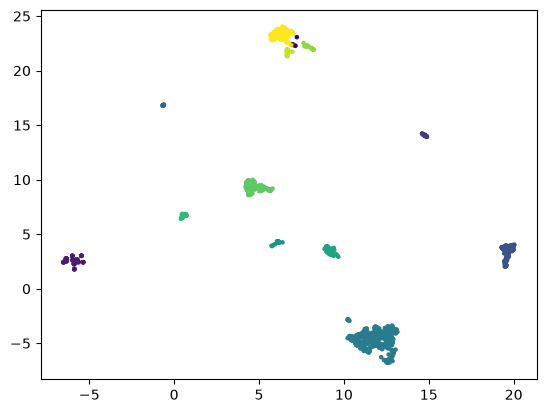

In [63]:
plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=labels,
    s=5
)

In [64]:
pd.Series(labels).value_counts().sort_index()

-1       7
 0      78
 1      38
 2     116
 3      16
 4     364
 5      30
 6      66
 7      41
 8     114
 9      28
 10     26
 11    135
Name: count, dtype: int64

In [65]:
needs

,need_id,need_text,cluster
0,N_ebc9559a424de306b0dc1b4a,Некоммерческой организации требуется специалист в области дизайна. Задача — Создание 3D-модели животных для печати на 3D-принтере и анимированной заставки под новый логотип проекта. Модель необходима для брендированной продукции и заставка — для идентификации проекта. Требуется техническое задание и примеры для ориентира. Ожидаемый результат — комплект элементов фирменного стиля. Формат работы: дистанционно.,4
1,N_f2365df8c9e0e164bcfe642f,"Некоммерческой организации требуется специалист по фото, видео или анимации. Задача — создать анимационный ролик в игровом стиле, объясняющий медицинский процесс. Необходимы иллюстрации персонажей и плавная анимация. Длительность 3-4 минуты. Ролик должен быть в формате MP4, оптимизирован для соцсетей. Важно, чтобы анимация была понятной и эмоционально нейтральной, чтобы снизить стресс у аудитории. Ожидаемый результат — готовый анимационный ролик. Формат работы: дистанционно.",3
2,N_f736b2786a4ba70e69b82c54,"Некоммерческой организации требуется специалист по фото, видео или анимации. Задача — создать серию 3D-анимаций сердца с эффектом кинцуги, а также анимационные обложки для подкаста. Сердце должно быть условным, с трещинами, заполняемыми золотыми швами. Также требуется 24 анимационных обложки в заданных цветовых решениях. Видео должны быть оптимизированы для веба, в формате WebM/MP4/GIF, размер 1080х1080 px. Ожидаемый результат — готовый анимационный ролик. Формат работы: дистанционно.",3
3,N_d7b293dde3307f437cd86295,"Некоммерческой организации требуется специалист по фото, видео или анимации. Задача — Создать 2D-анимацию из нескольких кадров, включая элементы, которые помогут привлечь внимание к благотворительной акции. Анимация должна быть в формате видео, вертикальной ориентации, длительностью до 1 минуты. Важно использовать HD-качество. Результат будет использоваться в социальных сетях и на экранах в общественном транспорте. Ожидаемый результат — готовый анимационный ролик. Формат работы: дистанционно.",3
4,N_7d3e725a4160d813ab382bed,"Некоммерческой организации требуется специалист по маркетингу и коммуникациям. Задача — разработать стратегию развития аудитории и ведения группы в социальной сети. Группа имеет низкий охват и вовлеченность. Необходимо составить план коммуникации, настроить email-рассылки и разработать контент-план для повышения активности подписчиков. Ожидаемый результат — план маркетинговых коммуникаций. Формат работы: дистанционно.",6
...,...,...,...
1054,N_1e3385a4f9d52791a4b06f41,"Фонду в регионе требуется фотограф: необходимо снять мероприятие с участием подопечных. Участие каждого человека в съёмке предварительно согласуется с ним или его законным представителем, а условия работы — с куратором фонда. Ожидаемый результат — обработанная серия фотографий. Формат работы: очно.",0
1055,N_90e47302e9290b57ad07284f,"Фонду, работающему вдали от областного центра, требуется фотограф: необходимо провести фотосъёмку работы фонда в нескольких населённых пунктах. Фонд заранее согласует исполнителя, дату, объём работ и участие подопечных в съёмке. Ожидаемый результат — обработанная серия фотографий. Формат работы: очно.",0
1056,N_8bcb1eb0765df7c3cbf84c3e,"Фонду, проводящему мероприятие для пожилых подопечных, требуется фотограф: необходимо снять мероприятие с участием подопечных. После выполнения нужен краткий отчёт для куратора; участие людей в съёмке допускается только с их согласия. Ожидаемый результат — обработанная серия фотографий. Формат работы: очно.",0
1057,N_cf2c122a5c2dff0e31b3a313,"Фонду, работающему в удалённых населённых пунктах, требуется фотограф: необходимо провести фотосъёмку работы фонда в нескольких населённых пунктах. Условия, стоимость и участие подопечных в съёмке заранее подтверждаются фондом. Ожидаемый результат — обработанная серия фотографий. Формат работы: очно.",0


In [91]:
for cluster in sorted(needs["cluster"].unique()):
    print("=" * 100)
    print(f"Кластер {cluster}")
    print(f"Количество: {(needs.cluster == cluster).sum()}")

    sample = needs.loc[
        needs.cluster == cluster,
        "need_text"
    ].sample(min(2, (needs.cluster == cluster).sum()), random_state=42)

    for i, text in enumerate(sample, 1):
        print(f"\n{i}. {text[:300]}...\n")

Кластер -1
Количество: 7

1. Некоммерческой организации требуется специалист по подготовке и редактированию текстов. Задача — Выполнить корректорскую вычитку статьи. Проверить текст на грамматические и пунктуационные ошибки, а также на соответствие нормам русского языка. Ожидаемый результат — вычитанный текст. Формат работы: ди...


2. Некоммерческой организации требуется специалист по подготовке и редактированию текстов. Задача — отредактировать и сократить тексты, сохранив их эмоциональную составляющую. Также требуется проверить статьи на грамматические и пунктуационные ошибки. Ожидаемый результат — вычитанный текст. Формат рабо...

Кластер 0
Количество: 78

1. Пожилому человеку, получающему поддержку фонда, требуется электрик: необходимо заменить выключатель и проверить участок проводки. После выполнения нужен краткий отчёт для куратора. Ожидаемый результат — безопасно работающий участок электросети. Формат работы: очно....


2. Пожилому человеку в небольшом населённом пункте требуе

In [93]:
cluster_info = {
    -1: {
        "name": "Корректура и вычитка текстов",
        "description": "Проверка и корректура статей, текстов для сайта и соцсетей на грамматику, пунктуацию и стилистику. Включает также верстку и редактирование."
    },
    0: {
        "name": "Бытовая помощь и ремонт",
        "description": "Задачи от пожилых подопечных: электрика, уборка, помощь по хозяйству, работа на участке. Требуют очного присутствия."
    },
    1: {
        "name": "Переводческие услуги",
        "description": "Письменный перевод (русский-английский и обратно), включая субтитры и адаптацию текстов для разных аудиторий."
    },
    2: {
        "name": "Юридические услуги",
        "description": "Юридические консультации, проверка договоров, помощь в оформлении опеки, инвалидности, защита прав пациентов."
    },
    3: {
        "name": "Фото, видео или анимации",
        "description": "Создание анимационных роликов, 3D-анимации, тизеров, видеомонтаж для продвижения и обучения. Включает работу с персонажами, эффектами и озвучкой."
    },
    4: {
        "name": "Дизайн",
        "description": "Создание логотипов, баннеров, фирменного стиля, верстка буклетов, отчетов, иллюстраций и инфографики."
    },
    5: {
        "name": "Аналитика и исследования",
        "description": "Сбор и систематизация данных, создание баз контактов, подготовка отчетов и презентаций с диаграммами."
    },
    6: {
        "name": "Маркетинг и коммуникации",
        "description": "Стратегический маркетинг: разработка SMM-стратегий, работа с блогерами, email-маркетинг, анализ аудитории."
    },
    7: {
        "name": "Финансы и фандрайзинг",
        "description": "Привлечение пожертвований, настройка рекламы, аудит сайта для улучшения конверсии, разработка стратегий привлечения доноров."
    },
    8: {
        "name": "IT и цифровые решения",
        "description": "Разработка сайтов, CRM, интеграция платежных систем, настройка почты, SEO-аудит, создание лендингов."
    },
    9: {
        "name": "Редактура текстов (средние и большие объемы)",
        "description": "Вычитка и редактура текстов объемом от 3 до 60 страниц: статей, интервью, сборников, FAQ. Включает работу со структурой и цитатами."
    },
    10: {
        "name": "Транскрипция и аудиообработка",
        "description": "Расшифровка аудио- и видеоматериалов (интервью, лекции, уроки), транскрибация с последующей редактурой текста."
    },
    11: {
        "name": "Создание контента (тексты и истории)",
        "description": "Написание эмоциональных историй о подопечных, создание текстов для сбора средств, соцсетей, писем и образовательных материалов."
    }
}

In [94]:
needs_plot = needs.copy()

text_clusters = {-1, 9, 11}

needs_plot["cluster_name"] = needs_plot["cluster"].apply(
    lambda x: "Тексты и редактура"
    if x in text_clusters
    else cluster_info[x]["name"]
)

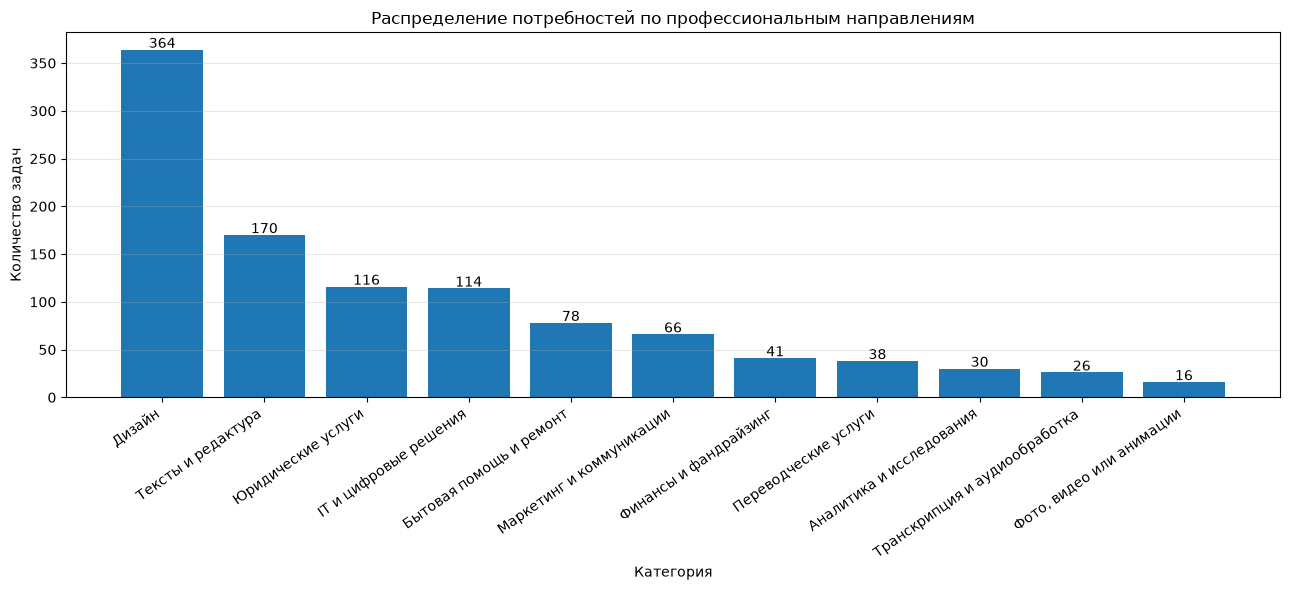

In [95]:
import matplotlib.pyplot as plt

counts = (
    needs_plot["cluster_name"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(13, 6))

bars = plt.bar(counts.index, counts.values)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 2,
        str(int(h)),
        ha="center",
        fontsize=10
    )

plt.title("Распределение потребностей по профессиональным направлениям")
plt.xlabel("Категория")
plt.ylabel("Количество задач")

plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
provider_embeddings = model.encode(
    providers["profile_summary"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches: 100%|█████████████████████████████████████████████████████████████████████████| 63/63 [00:17<00:00,  3.54it/s]


In [12]:
umap = UMAP(
    n_neighbors=50,
    min_dist=0.2,
    metric="cosine",
    random_state=42,
)
embedding_2d = umap.fit_transform(provider_embeddings)

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)
provider_labels = clusterer.fit_predict(embedding_2d)

/home/User25/user25/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [13]:
providers["cluster"] = provider_labels

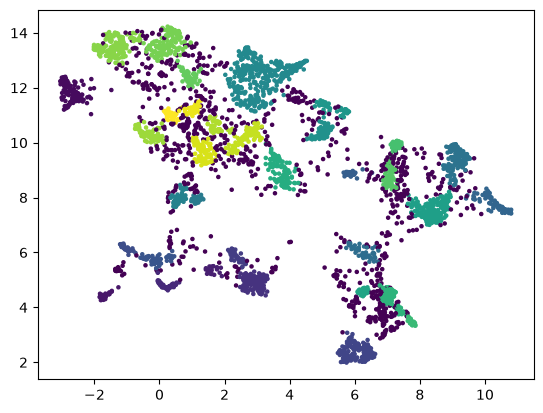

In [14]:
plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=provider_labels,
    s=5
)

In [158]:
providers["cluster"].value_counts().sort_index()

cluster
-1     916
 0     129
 1      46
 2      27
 3      60
 4     147
 5      51
 6     155
 7      42
 8      69
 9      45
 10     97
 11     46
 12    147
 13     36
 14     72
 15    363
 16     83
 17     58
 18    202
 19     50
 20    109
 21     98
 22     40
 23     51
 24     77
 25     53
 26    150
 27    185
 28     79
 29     38
 30    110
 31     92
 32     37
 33     46
Name: count, dtype: int64

In [159]:
for cluster in sorted(providers["cluster"].unique()):

    print("=" * 80)
    print(f"Кластер {cluster}")
    print("=" * 80)

    sample = providers.loc[
        providers.cluster == cluster,
        "profile_summary"
    ].sample(
        min(5, (providers.cluster == cluster).sum()),
        random_state=42
    )

    for text in sample:
        print(text[:250])
        print()

Кластер -1
Специализация включает разработку логотипов, фирменного стиля и полиграфических материалов. Предоставляются исходные файлы в различных форматах, подбор цветовой палитры и шрифтов, а также дополнительные элементы брендинга. Возможно создание брендбука

Предоставляет услуги по мелкому бытовому ремонту. Специализация включает сантехнические и электромонтажные работы, установку и подключение бытовой техники, сборку мебели, а также ремонт окон. Объём работ охватывает замену элементов сантехники и элект

Специалист по созданию презентаций. Осуществляет разработку структуры слайдов, дизайн под цели клиента, обновление устаревших материалов. Предоставляет неограниченное количество правок. Условия и сроки выполнения согласовываются индивидуально.

Предоставляется образовательная программа по колористике для парикмахеров. Обучение включает практические занятия по осветлению, закрашиванию седины, коррекции ошибок окрашивания и работе с цветом. Курс ориентирован на повышение квалификаци

In [30]:
cluster_info = {
    -1: {
        "name": "Шум (неклассифицированные специалисты)",
        "description": "Разрозненные специализации, которые не попали в основные кластеры. Включает дизайн, бытовой ремонт, обучение, финансовые консультации и другие редкие услуги. Требует ручного распределения по существующим категориям."
    },
    0: {
        "name": "Мероприятия и анимация",
        "description": "Организация детских и корпоративных мероприятий, анимационные услуги с использованием ростовых кукол, световые и пиксельные шоу, вокальные выступления, услуги ведущих на торжествах и праздниках."
    },
    1: {
        "name": "Садоводство и ландшафт",
        "description": "Уход за садом и участком: покос травы, обрезка деревьев и кустарников, прополка, обработка растений от вредителей, удобрение, полив, сезонная подготовка участка."
    },
    2: {
        "name": "Ремонт газового оборудования",
        "description": "Диагностика, ремонт и обслуживание газовых колонок, котлов, плит и отопительных систем. Включает промывку теплообменников, замену компонентов, сезонное обслуживание."
    },
    3: {
        "name": "Кровельные и строительные работы",
        "description": "Ремонт и монтаж кровли различных типов, гидроизоляция, утепление, работа с металлочерепицей, профнастилом и мягкой кровлей. Установка поручней и мелкие строительные работы."
    },
    4: {
        "name": "IT-поддержка и ремонт ПК",
        "description": "Ремонт компьютеров, ноутбуков, моноблоков. Установка и настройка операционных систем и программного обеспечения. Диагностика неисправностей, замена комплектующих, восстановление данных, чистка техники, удаление вирусов."
    },
    5: {
        "name": "Компьютерный мастер (обслуживание и апгрейд)",
        "description": "Профессиональное обслуживание компьютерной техники: чистка от пыли, замена термопасты, модернизация комплектующих, сборка ПК, настройка под задачи пользователя."
    },
    6: {
        "name": "Парикмахерские услуги",
        "description": "Стрижки, окрашивание, кератиновое выпрямление, ботокс для волос, наращивание, вечерние прически, укладки, плетение кос. Работа в салоне и с выездом на дом."
    },
    7: {
        "name": "Грузоперевозки и такелаж",
        "description": "Перевозка грузов, квартирные и офисные переезды, такелажные работы, подъем и перемещение крупногабаритной мебели, сборка-разборка мебели, вывоз мусора."
    },
    8: {
        "name": "Техническая поддержка и ремонт электроники",
        "description": "Ремонт электронной техники: смартфоны, ноутбуки, компьютеры, роботы-пылесосы. Установка и настройка ПО, драйверов, операционных систем. Диагностика аппаратных и программных неисправностей."
    },
    9: {
        "name": "Гранты и фандрайзинг",
        "description": "Подготовка и сопровождение грантовых заявок, поиск финансирования, разработка проектов, формирование бюджета и календарного плана, отчетность по грантам."
    },
    10: {
        "name": "Налоговые декларации",
        "description": "Заполнение и подача налоговых деклараций 3-НДФЛ, оформление налоговых вычетов (на обучение, лечение, имущество), консультации по налоговому законодательству."
    },
    11: {
        "name": "Обучение программированию",
        "description": "Обучение программированию на Python, Java, Roblox, веб-разработке. Индивидуальные и групповые занятия для детей и взрослых. Включает создание игр, приложений и веб-сервисов."
    },
    12: {
        "name": "Бухгалтерские услуги",
        "description": "Ведение бухгалтерского учета для ИП и ООО, подготовка и сдача отчетности, расчет налогов и взносов, кадровое делопроизводство, работа с маркетплейсами, учет товарно-материальных ценностей."
    },
    13: {
        "name": "Дизайн интерьеров",
        "description": "Разработка дизайн-проектов интерьеров: планировка, 3D-визуализация, подбор материалов и мебели, создание рабочей документации, авторский надзор за реализацией."
    },
    14: {
        "name": "Дизайн интерьеров с технической документацией",
        "description": "Создание дизайн-проектов с полным пакетом чертежей, спецификаций материалов, технической документацией. Включает выезд на замеры, планировочные решения и координацию с подрядчиками."
    },
    15: {
        "name": "Маркетинг и SMM",
        "description": "Разработка SMM-стратегий, ведение социальных сетей, создание контент-планов, настройка контекстной рекламы, работа с блогерами, анализ аудитории и конкурентов, повышение вовлеченности."
    },
    16: {
        "name": "Текстовые услуги (редактура, набор)",
        "description": "Редактирование и корректура текстов, набор текста, подготовка конспектов, документов, презентаций. Включает проверку грамматики, орфографии и синтаксиса."
    },
    17: {
        "name": "Переводческие услуги",
        "description": "Письменный и устный перевод с английского, испанского, китайского на русский и обратно. Адаптация текстов, перевод документов, субтитров, сценариев."
    },
    18: {
        "name": "Бухгалтерия (расчет зарплаты и маркетплейсы)",
        "description": "Расчет заработной платы, подготовка квартальной отчетности (РСВ, 6-НДФЛ, ЕФС-1), кадровое делопроизводство, ведение учета на маркетплейсах, работа с первичной документацией."
    },
    19: {
        "name": "Обучение маникюру",
        "description": "Курсы маникюра и педикюра для начинающих, обучение техникам наращивания ногтей, работе с гель-лаками, укреплению ногтей, дезинфекции и санитарным нормам."
    },
    20: {
        "name": "IT-разработка и 1С",
        "description": "Разработка AI-агентов, автоматизация бизнес-процессов, настройка и сопровождение 1С, интеграция с CRM и маркетплейсами, создание MES-систем, управление IT-проектами."
    },
    21: {
        "name": "Обучение визажу, бровистике и массажу",
        "description": "Курсы визажа, бровистики, ламинирования ресниц, массажа. Базовое и продвинутое обучение с практическими занятиями, работой с моделями и сертификацией."
    },
    22: {
        "name": "Наращивание ресниц (услуги и обучение)",
        "description": "Услуги наращивания и ламинирования ресниц. Индивидуальное обучение техникам наращивания, работа с LED-лампой, подбор объема, изгиба и длины. Практика на моделях."
    },
    23: {
        "name": "Юридические услуги (гражданское, трудовое, семейное право)",
        "description": "Консультации по гражданскому, трудовому, семейному, договорному и имущественному праву. Подготовка исковых заявлений, договоров, сопровождение в судах и государственных органах."
    },
    24: {
        "name": "Уголовное право и исполнительное производство",
        "description": "Юридическая поддержка по уголовным делам, сопровождение исполнительных производств, обжалование действий приставов, подготовка процессуальных документов, защита в судах."
    },
    25: {
        "name": "ИИ-визуализация и нейросети",
        "description": "Создание изображений, портретов, рекламных креативов и видео с использованием нейросетей. Генерация персонализированного контента, обработка фото, ретушь, цветокоррекция."
    },
    26: {
        "name": "Видеомонтаж и аудиопроизводство",
        "description": "Монтаж видеороликов, создание подкастов, свадебных и корпоративных фильмов. Цветокоррекция, спецэффекты, добавление титров и музыки, саунд-дизайн."
    },
    27: {
        "name": "Фотография",
        "description": "Фотосъемка мероприятий, портретов, предметная и фуд-фотография. Работа с различными форматами (свадьбы, семейные, детские фотосессии), профессиональная обработка снимков."
    },
    28: {
        "name": "Художественные портреты и иллюстрации",
        "description": "Создание портретов по фото в различных техниках: карандаш, акварель, масло на холсте. Иллюстрации для книг, открыток, постеров. Индивидуальный подход, передача характера и настроения."
    },
    29: {
        "name": "Графический дизайн и презентации",
        "description": "Создание инфографики, дизайн карточек товаров, разработка презентаций, подготовка информационных материалов, визуальное оформление данных, создание цифровых приглашений."
    },
    30: {
        "name": "Веб-разработка и SEO",
        "description": "Создание сайтов на Tilda, Figma, верстка интерфейсов, SEO-продвижение, наполнение магазинов, разработка корпоративных сайтов, интернет-магазинов и веб-сервисов."
    },
    31: {
        "name": "Графический дизайн (логотипы, фирменный стиль)",
        "description": "Разработка логотипов, фирменного стиля, брендбуков, визиток, баннеров, иллюстраций, оформление социальных сетей, создание дизайна печатной продукции."
    },
    32: {
        "name": "Наружная реклама",
        "description": "Проектирование, изготовление и монтаж наружной рекламы: световые вывески, объемные буквы, баннеры, наклейки, брендирование транспорта. Полный цикл от аудита до установки."
    },
    33: {
        "name": "Печатные услуги",
        "description": "Печать на текстиле, полиграфия, изготовление наклеек, визиток, баннеров, табличек. Широкоформатная печать, ламинация, контурная резка, изготовление этикеток."
    }
}

In [16]:
import numpy as np

cluster_centers = {}

for cluster in sorted(providers["cluster"].unique()):
    if cluster == -1:
        continue

    idx = providers["cluster"] == cluster
    cluster_centers[cluster] = provider_embeddings[idx].mean(axis=0)
    cluster_centers[cluster] /= np.linalg.norm(cluster_centers[cluster])

cluster_ids = sorted(cluster_centers.keys())

centers = np.vstack([
    cluster_centers[c]
    for c in cluster_ids
])

noise_idx = providers["cluster"] == -1
noise_embeddings = provider_embeddings[noise_idx]
similarity = noise_embeddings @ centers.T

best = similarity.argmax(axis=1)
best_score = similarity.max(axis=1)
best_cluster = np.array(cluster_ids)[best]

noise = providers.loc[noise_idx].copy()
noise["suggested_cluster"] = best_cluster
noise["similarity"] = best_score

In [27]:

providers_final = providers.copy()
noise_mask = providers_final["cluster"] == -1
noise_indices = providers_final.index[noise_mask]

threshold = 0.60

good = best_score >= threshold

providers_final.loc[
    noise_indices[good],
    "cluster"
] = best_cluster[good]

In [28]:
providers_final["cluster"].value_counts().sort_index()

cluster
0     141
1      59
2      31
3      63
4     161
5      61
6     166
7      63
8      81
9      55
10    100
11     98
12    166
13     60
14     98
15    401
16    112
17     84
18    227
19     71
20    133
21    178
22     51
23     80
24    163
25     90
26    204
27    211
28    108
29     77
30    135
31    145
32     61
33     72
Name: count, dtype: int64

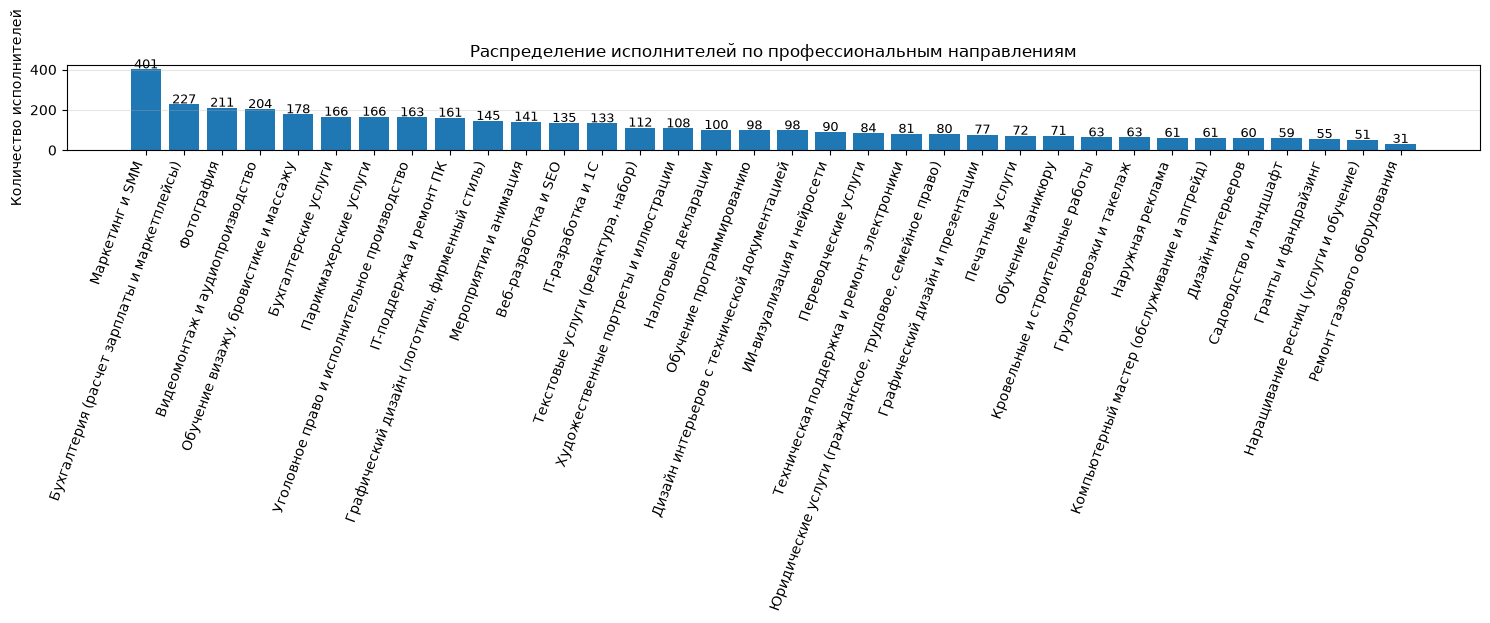

In [31]:
import matplotlib.pyplot as plt
providers_final["cluster_name"] = providers_final["cluster"].map(
    lambda x: cluster_info[x]["name"]
)

counts = (
    providers_final["cluster_name"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15,6))

bars = plt.bar(
    counts.index,
    counts.values
)

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 5,
        str(int(h)),
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=70, ha="right")

plt.ylabel("Количество исполнителей")
plt.title("Распределение исполнителей по профессиональным направлениям")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
merged_clusters = {

    0: "Мероприятия и анимация",
    1: "Садоводство и ландшафт",
    2: "Строительство и ремонт",
    3: "Строительство и ремонт",

    4: "IT",
    5: "IT",
    20: "IT",
    30: "IT",



    6: "Бьюти-индустрия (услуги и обучение)",
    19: "Бьюти-индустрия (услуги и обучение)",
    21: "Бьюти-индустрия (услуги и обучение)",
    22: "Бьюти-индустрия (услуги и обучение)",

    7: "Грузоперевозки",

    8: "Строительство и ремонт",

    9: "Фандрайзинг и гранты",

    10: "Бухгалтерия и налоги",
    12: "Бухгалтерия и налоги",
    18: "Бухгалтерия и налоги",

    11: "Обучение программированию",

    13: "Дизайн",
    14: "Дизайн",

    15: "Маркетинг",

    16: "Текстовые услуги",

    17: "Переводы",

    23: "Юридические услуги",
    24: "Юридические услуги",

    25: "Дизайн",
    26: "Дизайн",
    27: "Дизайн",
    28: "Дизайн",
    29: "Дизайн",
    31: "Дизайн",
    32: "Дизайн",
    33: "Дизайн",
}
providers_final["category"] = providers_final["cluster"].map(merged_clusters)

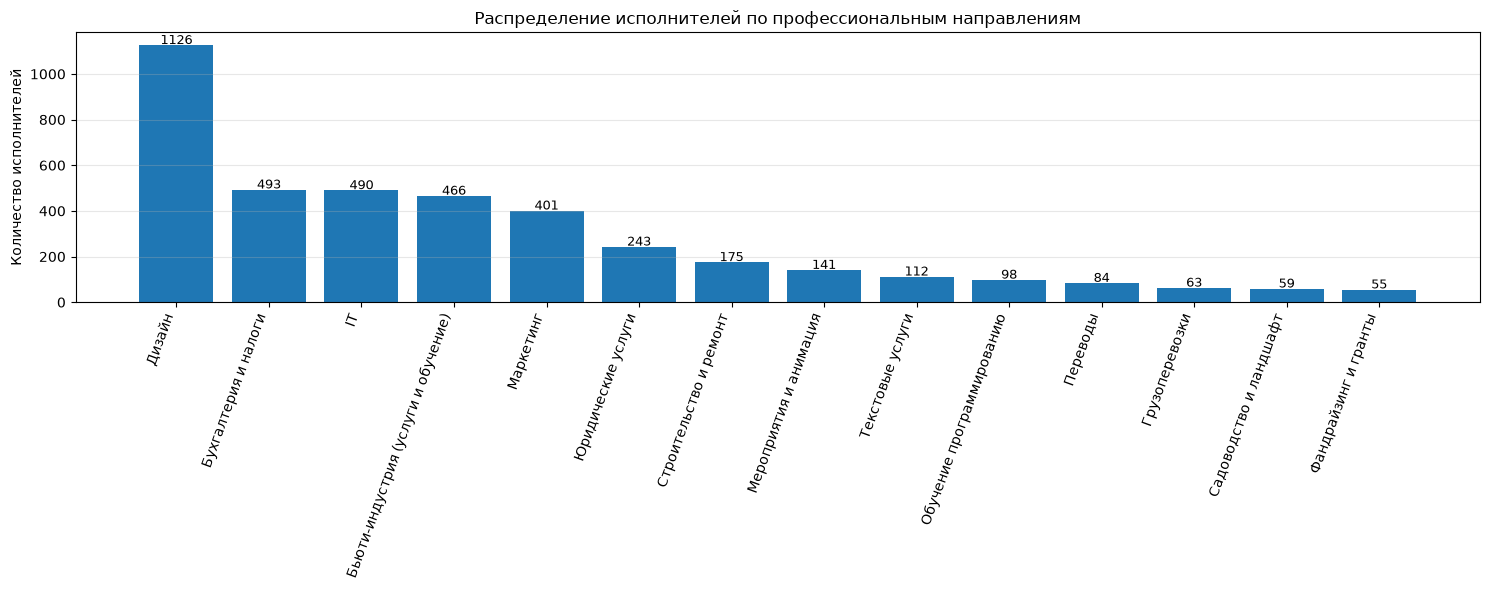

In [42]:
import matplotlib.pyplot as plt
providers_final["cluster_name"] = providers_final["cluster"].map(
    lambda x: cluster_info[x]["name"]
)

counts = (
    providers_final["category"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15,6))

bars = plt.bar(
    counts.index,
    counts.values
)

for bar in bars:
    h = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 5,
        str(int(h)),
        ha="center",
        fontsize=9
    )

plt.xticks(rotation=70, ha="right")

plt.ylabel("Количество исполнителей")
plt.title("Распределение исполнителей по профессиональным направлениям")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()